In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb


In [ ]:
df = pd.read_csv("final_internship_data.csv")
df.shape

In [3]:
summary = []

duplicates = df.duplicated().sum()

for col in df.columns:
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100

    summary.append([
        col,
        df[col].dtype,
        null_count,
        df[col].nunique()])

summary_df = pd.DataFrame(
    summary,
    columns=["Column", "Type", "Missing Values",  "Unique Values"])

print("Number of duplicate rows:", duplicates)

summary_df

Number of duplicate rows: 0


,Column,Type,Missing Values,Unique Values
0,User ID,object,0,21537
1,User Name,object,0,19177
2,Driver Name,object,0,19122
3,Car Condition,object,0,4
4,Weather,object,0,5
5,Traffic Condition,object,0,3
6,key,object,0,3474
7,fare_amount,float64,0,503
8,pickup_datetime,object,0,21388
9,pickup_longitude,float64,0,17685


In [4]:
df['fare_amount'].value_counts()

#df['Driver Name'].value_counts()

,count
fare_amount,
6.50,1032
4.50,905
8.50,839
5.30,624
4.90,611
...,...
40.54,1
33.29,1
29.40,1


Data cleaning

In [5]:
#deleting

columns_to_drop = ['Driver Name', 'User Name', 'key','User ID']
df = df.drop(columns=columns_to_drop)

In [6]:
# فصل ال target

target = "fare_amount"
y = df[target]
X = df.drop(columns=[target])

####train - test before preproc.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature engineerimg

In [8]:
#Feature Engineering of time-s


df['Times of day'] = pd.cut(df['hour'],bins=[-1,6,12,18,24],labels=['Night','Morning','Afternoon','Evening'])

df['Peak hours'] = df['hour'].isin([7,8,9,16,17,18]).astype(int)

df['IS weekend'] = df["weekday"].isin([4,5,6]).astype(int)


def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Fall'

df['month season'] = df['month'].apply(get_season)

df['distance_hour'] = df['distance'] * df['hour']


df = df.drop('pickup_datetime', axis=1)
df.head()

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,...,lga_dist,sol_dist,nyc_dist,distance,bearing,Times of day,Peak hours,IS weekend,month season,distance_hour
0,Very Good,windy,Congested Traffic,4.5,-1.288826,0.710721,-1.288779,0.710563,1,17,...,14.342611,34.543548,27.572573,1.030764,-2.918897,Afternoon,1,0,Summer,17.522987
1,Excellent,cloudy,Flow Traffic,16.9,-1.291824,0.710546,-1.291182,0.711780,1,16,...,23.130775,15.125872,8.755732,8.450134,-0.375217,Afternoon,1,0,Winter,135.202138
2,Bad,stormy,Congested Traffic,5.7,-1.291242,0.711418,-1.291391,0.711231,2,0,...,19.865289,17.722624,9.847344,1.389525,2.599961,Night,0,0,Summer,0.000000
3,Very Good,stormy,Flow Traffic,7.7,-1.291319,0.710927,-1.291396,0.711363,1,4,...,21.063132,15.738963,7.703421,2.799270,0.133905,Night,0,1,Spring,11.197081
4,Bad,stormy,Congested Traffic,5.3,-1.290987,0.711536,-1.290787,0.711811,1,7,...,15.219339,23.732406,15.600745,1.999157,-0.502703,Morning,1,0,Spring,13.994098


/tmp/ipykernel_5802/3499033500.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


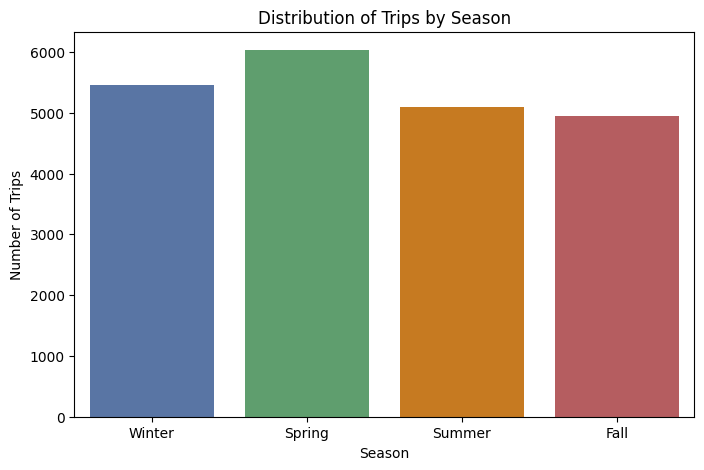

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
order = ['Winter','Spring','Summer','Fall']
sns.countplot(
    x='month season',
    data=df,
    order=order,
    palette=['#4C72B0', '#55A868', '#E17C05', '#C44E52']
)

plt.title("Distribution of Trips by Season")
plt.xlabel("Season")
plt.ylabel("Number of Trips")

plt.show()

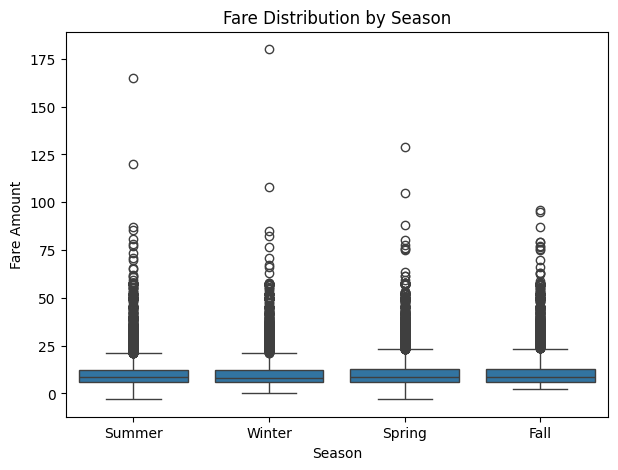

In [10]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='month season',
    y='fare_amount',
    data=df
)

plt.title("Fare Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Fare Amount")

plt.show()

##Data cleaning

##OUTLIERS

In [11]:
numeric_cols = ['fare_amount','distance','passenger_count','bearing','jfk_dist','ewr_dist','lga_dist','sol_dist','nyc_dist']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers, min={df[col].min()}, max={df[col].max()}")

fare_amount: 1889 outliers, min=-3.0, max=180.0
distance: 1857 outliers, min=0.0, max=8667.542104
passenger_count: 2321 outliers, min=0, max=6
bearing: 0 outliers, min=-3.140475549, max=3.141592654
jfk_dist: 2544 outliers, min=1.15699468, max=30130.80786
ewr_dist: 1206 outliers, min=1.470598941, max=30165.32549
lga_dist: 963 outliers, min=0.635375691, max=30165.02508
sol_dist: 794 outliers, min=5.415659034, max=30157.14034
nyc_dist: 935 outliers, min=0.47419534, max=30160.01986


In [12]:
#handeling fare amount

df = df[df['fare_amount'] > 0]
df.loc[df['fare_amount'] < 0, 'fare_amount'] = np.nan
df['fare_amount'] = df['fare_amount'].fillna(df['fare_amount'].median())

In [13]:
# handling distance
df['distance'] = df['distance'].clip(lower=0.1, upper=100)

# handling passengers
df.loc[df['passenger_count'] == 0, 'passenger_count'] = np.nan
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())

# handling airports distance
airport_cols = ['jfk_dist','ewr_dist','lga_dist','sol_dist','nyc_dist']
df[airport_cols] = df[airport_cols].clip(upper=200)

In [14]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,...,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing,Peak hours,IS weekend,distance_hour
count,21533.000000,21533.000000,21533.000000,21533.000000,21533.000000,21533.000000,21533.000000,21533.000000,21533.000000,21533.000000,...,21533.000000,21533.000000,21533.000000,21533.000000,21533.000000,21533.000000,21532.000000,21533.000000,21533.000000,21533.000000
mean,11.341804,-1.265078,0.696768,-1.265317,0.696613,1.661914,13.483955,15.675103,6.255190,3.032044,...,45.247490,39.217871,23.383942,22.818863,15.246920,3.493111,0.301039,0.282636,0.437143,220.094766
std,9.616350,0.183450,0.115971,0.182601,0.107311,1.278960,6.527873,8.682697,3.446876,1.966984,...,23.287762,24.378512,26.395074,26.819827,27.919616,5.787214,1.803466,0.450291,0.496045,4931.545961
min,0.010000,-1.303583,-1.291664,-1.477495,-1.291655,1.000000,0.000000,1.000000,1.000000,0.000000,...,1.156995,1.470599,0.635376,5.415659,0.474195,0.100000,-3.140476,0.000000,0.000000,0.000000
25%,6.000000,-1.291406,0.710957,-1.291390,0.710951,1.000000,9.000000,8.000000,3.000000,1.000000,...,41.332505,32.188007,17.081794,14.905784,7.169876,1.223250,-0.850590,0.000000,0.000000,11.907426
50%,8.500000,-1.291224,0.711270,-1.291197,0.711285,1.000000,14.000000,16.000000,6.000000,3.000000,...,42.525269,34.787419,19.557219,18.391719,10.497613,2.136282,-0.059399,0.000000,0.000000,25.677840
75%,12.500000,-1.290965,0.711527,-1.290909,0.711539,2.000000,19.000000,23.000000,9.000000,5.000000,...,43.799676,38.407948,22.186522,22.536572,14.572626,3.870102,2.206696,1.000000,1.000000,51.739929
max,180.000000,0.711503,7.000225,0.712137,0.721975,6.000000,23.000000,31.000000,12.000000,6.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,100.000000,3.141593,1.000000,1.000000,199300.146641


<Axes: xlabel='fare_amount'>

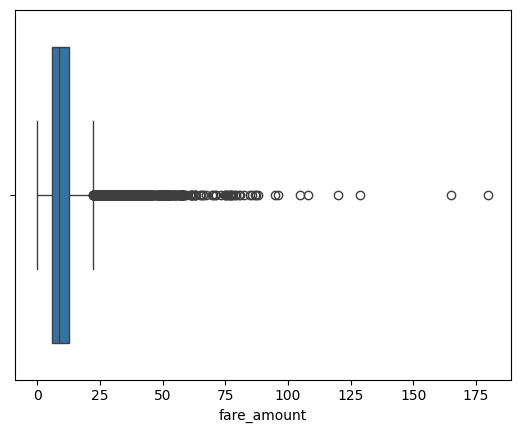

In [15]:
import seaborn as sns
sns.boxplot(x=df['fare_amount'])

##handeling missing values

In [16]:

numeric_cols = ['distance', 'bearing', 'dropoff_longitude', 'dropoff_latitude', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'passenger_count', 'distance_hour']
categorical_cols = ['car condition', 'weather', 'traffic condition', 'year', 'month', 'day', 'weekday', 'hour', 'Times of day']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()

df.isnull().sum()

,0
Car Condition,0
Weather,0
Traffic Condition,0
fare_amount,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0
hour,0


##MODELING

In [17]:
#Linear Regression (One-Hot + Scaling)

lr_categorical = ['Car Condition', 'Weather', 'Traffic Condition', 'year', 'month', 'day', 'weekday', 'hour', 'Times of day', 'month season']
lr_num = ['distance', 'bearing', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'passenger_count', 'distance_hour']

X_lr = pd.get_dummies(df[lr_categorical + lr_num], drop_first=True)

# Scaling for numircal
scaler = StandardScaler()
X_lr[lr_num] = scaler.fit_transform(X_lr[lr_num])

#split
y = df['fare_amount']
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y, test_size=0.2, random_state=42)

#training
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

#calculat RMSE
y_pred_lr = lr_model.predict(X_test_lr)
rmse = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 6.654168979492804


In [18]:
#Random Forest / XGBoost (Label Encoding للفئات، لا Scaling)

tree_categorical = ['Car Condition', 'Weather', 'Traffic Condition', 'year', 'month', 'day', 'weekday', 'hour', 'Times of day', 'month season']
tree_num = ['distance', 'bearing', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'passenger_count', 'distance_hour']

X_tree = df[tree_categorical + tree_num].copy()
for col in tree_categorical:
    le = LabelEncoder()
    X_tree[col] = le.fit_transform(X_tree[col])

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_tree, y, test_size=0.2, random_state=42)

In [19]:
# Random Forest
#training
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_tree, y_train_tree)

#Predictions
y_pred_rf = rf_model.predict(X_test_tree)

# calculat RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test_tree, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)


Random Forest RMSE: 3.898561193507226


In [20]:
#XGBoost
#training
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_tree, y_train_tree)

# calculat RMSE
y_pred_xgb = xgb_model.predict(X_test_tree)
rmse_xgb = np.sqrt(mean_squared_error(y_test_tree, y_pred_xgb))
print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 3.950521702922725


###Evaluation

In [21]:
#تقييم Linear Regression

y_pred_lr = lr_model.predict(X_test_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
mae_lr = mean_absolute_error(y_test_lr, y_pred_lr)
r2_lr = r2_score(y_test_lr, y_pred_lr)

print("Linear Regression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)

Linear Regression
RMSE: 6.654168979492804
MAE: 3.467606390991944
R2: 0.5129560296376326


In [22]:
#تقييم Random Forest

y_pred_rf = rf_model.predict(X_test_tree)

rmse_rf = np.sqrt(mean_squared_error(y_test_tree, y_pred_rf))
mae_rf = mean_absolute_error(y_test_tree, y_pred_rf)
r2_rf = r2_score(y_test_tree, y_pred_rf)

print("Random Forest")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)

Random Forest
RMSE: 3.898561193507226
MAE: 2.0117394773449857
R2: 0.8328181097342272


In [23]:
#تقييم XGBoost

y_pred_xgb = xgb_model.predict(X_test_tree)

rmse_xgb = np.sqrt(mean_squared_error(y_test_tree, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_tree, y_pred_xgb)
r2_xgb = r2_score(y_test_tree, y_pred_xgb)

print("XGBoost")
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)
print("R2:", r2_xgb)

XGBoost
RMSE: 3.950521702922725
MAE: 1.8591378428348122
R2: 0.8283319695917095


###Comparison

In [24]:
results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest","XGBoost"],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb],
    "MAE": [mae_lr, mae_rf, mae_xgb],
    "R2": [r2_lr, r2_rf, r2_xgb]
})

print(results)

               Model      RMSE       MAE        R2
0  Linear Regression  6.654169  3.467606  0.512956
1      Random Forest  3.898561  2.011739  0.832818
2            XGBoost  3.950522  1.859138  0.828332


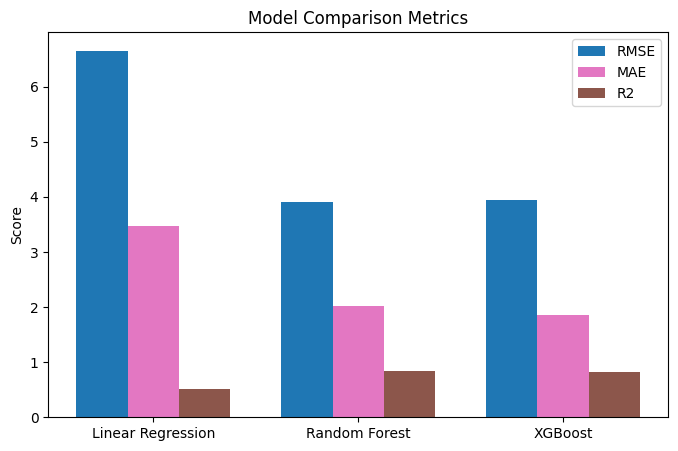

In [25]:
import matplotlib.pyplot as plt
import numpy as np

results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest","XGBoost"],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb],
    "MAE": [mae_lr, mae_rf, mae_xgb],
    "R2": [r2_lr, r2_rf, r2_xgb]
})

models = results['Model']
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, results['RMSE'], width, label='RMSE', color='#1f77b4')
plt.bar(x, results['MAE'], width, label='MAE', color='#e377c2')
plt.bar(x + width, results['R2'], width, label='R2', color='#8c564b')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison Metrics")
plt.legend()
plt.show()

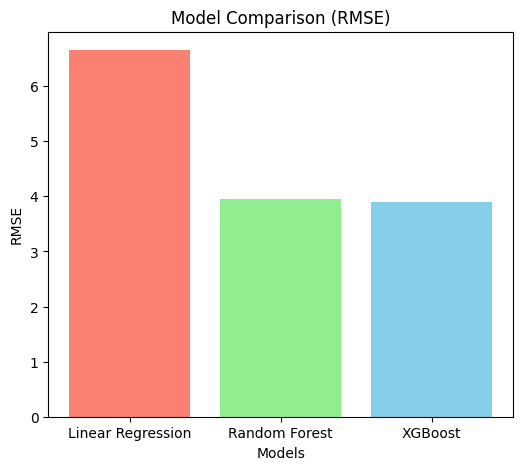

In [26]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest', 'XGBoost']
rmse_scores = [rmse_lr, rmse_xgb, rmse_rf]

colors = ['salmon', 'lightgreen', 'skyblue']

plt.figure(figsize=(6,5))
plt.bar(models, rmse_scores, color=colors)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Models")
plt.show()

##Validation

In [27]:
#cross validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    rf_model,
    X_tree,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

rmse_scores = -scores

print("RMSE for each fold:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

RMSE for each fold: [5.29213137 4.39316191 4.10999311 4.21443017 4.57343792]
Average RMSE: 4.516630898039318


In [28]:

'''#to more inhancing

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)'''

'#to more inhancing\n\nrf_model = RandomForestRegressor(\n    n_estimators=500,\n    max_depth=18,\n    min_samples_leaf=2,\n    random_state=42,\n    n_jobs=-1\n)'

In [29]:
'''#to enhance CV
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    rf_model,
    X_tree,
    y,
    scoring="neg_root_mean_squared_error",
    cv=kf
)

rmse_scores = -scores

print("RMSE per fold:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())'''

'#to enhance CV\nfrom sklearn.model_selection import KFold\n\nkf = KFold(n_splits=5, shuffle=True, random_state=42)\n\nscores = cross_val_score(\n    rf_model,\n    X_tree,\n    y,\n    scoring="neg_root_mean_squared_error",\n    cv=kf\n)\n\nrmse_scores = -scores\n\nprint("RMSE per fold:", rmse_scores)\nprint("Average RMSE:", rmse_scores.mean())'

<Axes: xlabel='fare_amount', ylabel='Count'>

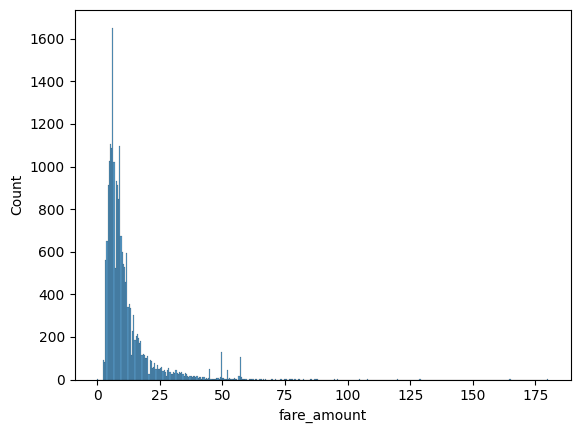

In [30]:
#may be a problem

sns.histplot(df['fare_amount'])

### (fare amount) showed a right-skewed distribution so we can use Transformation to improve model stability

## Hyperparameter Tuning

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_dist_rf = {
    "n_estimators": [100,200,300,400],
    "max_depth": [10,20,30,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ["sqrt","log2"]
}

rf_random = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_tree, y_train_tree)

print("Best RF Parameters:", rf_random.best_params_)

Best RF Parameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [32]:
best_rf = rf_random.best_estimator_

y_pred_rf = best_rf.predict(X_test_tree)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse_rf = np.sqrt(mean_squared_error(y_test_tree, y_pred_rf))

print("Tuned Random Forest RMSE:", rmse_rf)

Tuned Random Forest RMSE: 3.872524253394478


In [33]:
#xgboost

from xgboost import XGBRegressor

xgb = XGBRegressor(objective="reg:squarederror", random_state=42)

param_dist_xgb = {
    "n_estimators": [200,400,600],
    "max_depth": [3,5,7,10],
    "learning_rate": [0.01,0.05,0.1],
    "subsample": [0.7,0.8,1],
    "colsample_bytree": [0.7,0.8,1]
}

xgb_random = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_tree, y_train_tree)

print("Best XGB Parameters:", xgb_random.best_params_)

Best XGB Parameters: {'subsample': 0.8, 'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [34]:
best_xgb = xgb_random.best_estimator_

y_pred_xgb = best_xgb.predict(X_test_tree)

rmse_xgb = np.sqrt(mean_squared_error(y_test_tree, y_pred_xgb))

print("Tuned XGBoost RMSE:", rmse_xgb)

Tuned XGBoost RMSE: 3.7463589317437505


                 Model      RMSE
2        XGBoost Tuned  3.746359
1  Random Forest Tuned  3.872524
0    Linear Regression  6.654169


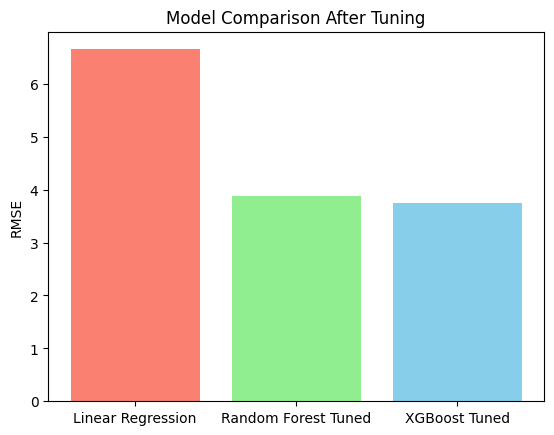

In [38]:
results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest Tuned","XGBoost Tuned"],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb]
})

print(results.sort_values("RMSE"))

import matplotlib.pyplot as plt
colors = ['salmon', 'lightgreen', 'skyblue']

plt.bar(results["Model"], results["RMSE"], color=colors)
plt.title("Model Comparison After Tuning")
plt.ylabel("RMSE")
plt.show()

In [48]:
# XGBoost Tuned

rmse_xgb = np.sqrt(mean_squared_error(y_test_tree, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_tree, y_pred_xgb)
r2_xgb = r2_score(y_test_tree, y_pred_xgb)

print("Final RMSE:", rmse_xgb)
print("Final MAE:", mae_xgb)
print("Final R2:", r2_xgb)

Final RMSE: 3.7463589317437505
Final MAE: 1.90772674870873
Final R2: 0.8456170666991101


In [44]:
#Random Forest Tuned

rmse_rf = np.sqrt(mean_squared_error(y_test_tree, y_pred_rf))
mae_rf = mean_absolute_error(y_test_tree, y_pred_rf)
r2_rf = r2_score(y_test_tree, y_pred_rf)

print("Final RF RMSE:", rmse_rf)
print("Final RF MAE:", mae_rf)
print("Final RF R2:", r2_rf)

Final RF RMSE: 3.872524253394478
Final RF MAE: 1.9868618872254533
Final RF R2: 0.8350437355428408


In [46]:
results = pd.DataFrame({
    "Model": ["Random Forest","XGBoost"],
    "RMSE": [rmse_rf, rmse_xgb],
    "MAE": [mae_rf, mae_xgb],
    "R2": [r2_rf, r2_xgb]
})

print(results)

           Model      RMSE       MAE        R2
0  Random Forest  3.872524  1.986862  0.835044
1        XGBoost  3.746359  1.907727  0.845617


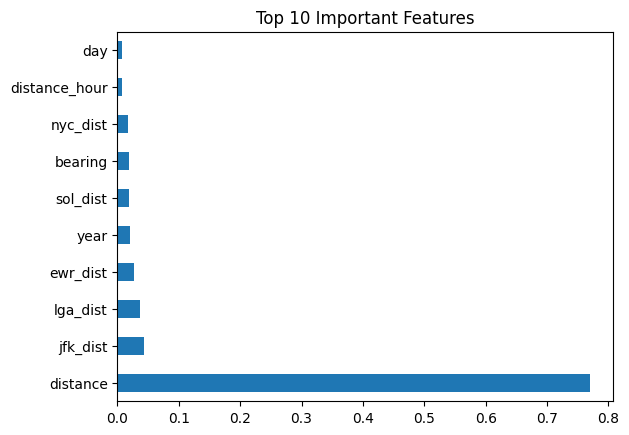

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

rf_model.fit(X_train_tree, y_train_tree)
importance = rf_model.feature_importances_

feat_imp = pd.Series(importance, index=X_tree.columns)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

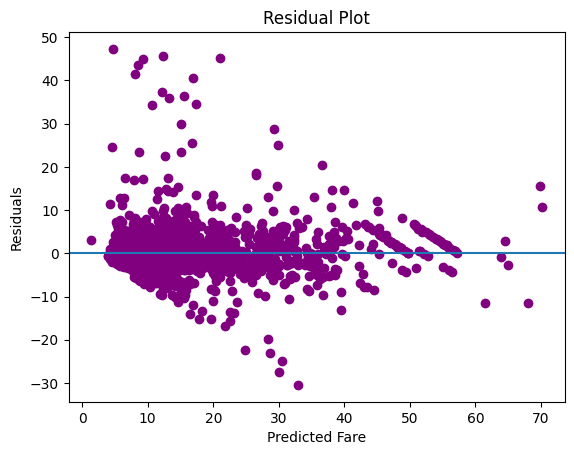

In [39]:
#Residual Analysis

residuals = y_test_tree - y_pred_xgb

plt.scatter(y_pred_xgb, residuals, color="Purple")
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.show()

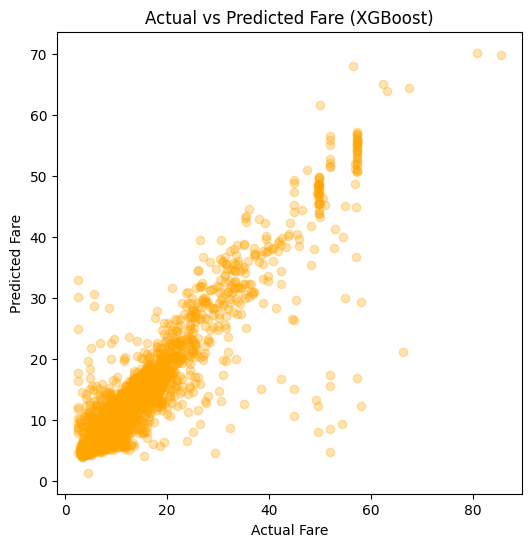

In [47]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_tree, y_pred_xgb, alpha=0.3, color="Orange")

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")

plt.title("Actual vs Predicted Fare (XGBoost)")

plt.show()

In [ ]:
import joblib

joblib.dump(xgb_model, "taxi_fare_model.pkl")

In [ ]:
joblib.dump(X_tree.columns.tolist(), "features.pkl")